# 物体検出

**物体検出（object detection）** は、画像中に写っている物体について「どこに」「何が」写っているかを推定するタスク。各物体を囲む矩形領域（バウンディングボックス）の位置と、その物体のクラスラベルの両方を出力する。

| タスク | 出力 |
| --- | --- |
| 画像分類（classification） | 画像全体に対する1つのクラスラベル |
| 物体検出（object detection） | 物体ごとのバウンディングボックス＋クラスラベル |
| セマンティックセグメンテーション（semantic segmentation） | ピクセルごとのクラスラベル（個体は区別しない） |
| インスタンスセグメンテーション（instance segmentation） | 物体ごとのピクセル単位マスク＋クラスラベル |

画像分類は「画像→記述」の写像だが、物体検出は1枚の画像から可変個の物体を検出する必要があるため、単純な分類問題より難しい。この可変長出力をどう扱うかという観点が、後続の各アルゴリズム（R-CNN系、YOLO/SSD系、FCOS、DETR系）の設計思想の違いにつながる。

---

**目次**

:::{toc}
:context: children
:depth: 1
:::

---

## タスクの定義

物体検出モデルは、画像 $I$ を入力として、物体の集合

$$
\{(b_i, c_i, s_i)\}_{i=1}^{N}
$$

を出力する。ここで

- $b_i = (x_{\min}, y_{\min}, x_{\max}, y_{\max})$：$i$番目のバウンディングボックスの座標
- $c_i$：クラスラベル
- $s_i$：信頼度スコア（confidence score）
- $N$：検出された物体数（画像ごとに可変）

というように、「可変個の (位置, クラス, スコア) の組」を予測する点が、固定長のベクトルを出力する分類・回帰と大きく異なる。

学習時の正解データ（ground truth）も同様に、画像ごとに $\{(b_i^{gt}, c_i^{gt})\}$ という可変個のボックス集合として与えられる。予測と正解をどう対応づけるか（マッチング）、対応づけられなかった予測やボックスをどう扱うかが、モデル設計上の主要な論点になる。

## 評価指標

### IoU（Intersection over Union）

**IoU（Intersection over Union、和集合に対する共通部分の割合）** は、2つの矩形領域 $A, B$ がどれだけ重なっているかを表す指標。

$$
\mathrm{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

$\mathrm{IoU} \in [0, 1]$ で、完全に一致すれば1、重なりがなければ0になる。物体検出では

- 予測ボックスと正解ボックスが「同じ物体を指しているか」の判定（例：$\mathrm{IoU} \geq 0.5$ なら正検出とみなす）
- 後述のNMSにおける重複ボックスの判定
- 後述のFaster R-CNNのアンカーへのラベル付け

など、検出パイプラインのあらゆる箇所で使われる最も基本的な指標。

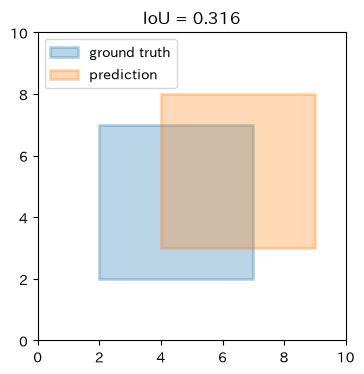

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib_fontja
import numpy as np


def box_iou(box1, box2):
    # box = (x_min, y_min, x_max, y_max)
    xa = max(box1[0], box2[0])
    ya = max(box1[1], box2[1])
    xb = min(box1[2], box2[2])
    yb = min(box1[3], box2[3])

    inter_w = max(0.0, xb - xa)
    inter_h = max(0.0, yb - ya)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


box_gt = (2, 2, 7, 7)
box_pred = (4, 3, 9, 8)
iou = box_iou(box_gt, box_pred)

fig, ax = plt.subplots(figsize=[4, 4])
ax.add_patch(patches.Rectangle((box_gt[0], box_gt[1]), box_gt[2] - box_gt[0], box_gt[3] - box_gt[1],
                                linewidth=2, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.3, label="ground truth"))
ax.add_patch(patches.Rectangle((box_pred[0], box_pred[1]), box_pred[2] - box_pred[0], box_pred[3] - box_pred[1],
                                linewidth=2, edgecolor="tab:orange", facecolor="tab:orange", alpha=0.3, label="prediction"))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_title(f"IoU = {iou:.3f}")
ax.legend(loc="upper left")
plt.show()

### NMS（Non-Maximum Suppression）

物体検出モデルは通常、1つの物体に対して多数の重複したボックスを予測する（後述のスライディングウィンドウ／アンカー／グリッドベースの手法では特に顕著）。**NMS（Non-Maximum Suppression、非最大値抑制）** は、この重複した検出結果から最も確からしい1つだけを残すための後処理アルゴリズム。

**アルゴリズム**

1. 検出結果を信頼度スコア $s_i$ の降順に並べる
2. 最もスコアが高いボックス $b$ を採用し、出力集合に加える
3. 残りのボックスのうち、$b$ とのIoUが閾値 $\tau$ 以上のもの（＝$b$ と同じ物体を指していると判断されるもの）を除去する
4. 残ったボックスに対して2〜3を繰り返す

$\tau$（典型的には $0.5$ 程度）は、どこまでの重なりを「同じ物体」とみなすかを決めるハイパーパラメータ。

keep indices: [np.int64(0), np.int64(3), np.int64(1)]


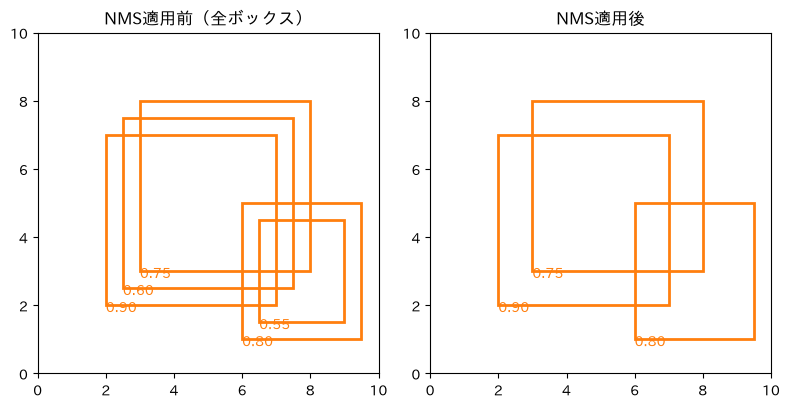

In [2]:
def nms(boxes, scores, iou_threshold=0.5):
    order = np.argsort(scores)[::-1]
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        rest = order[1:]
        ious = np.array([box_iou(boxes[i], boxes[j]) for j in rest])
        order = rest[ious < iou_threshold]
    return keep


rng = np.random.default_rng(0)
boxes = np.array([
    [2, 2, 7, 7],
    [3, 3, 8, 8],
    [2.5, 2.5, 7.5, 7.5],
    [6, 1, 9.5, 5],
    [6.5, 1.5, 9, 4.5],
])
scores = np.array([0.9, 0.75, 0.6, 0.8, 0.55])

keep = nms(boxes, scores, iou_threshold=0.5)
print("keep indices:", keep)

fig, axes = plt.subplots(1, 2, figsize=[8, 4])
titles = ["NMS適用前（全ボックス）", "NMS適用後"]
for ax, idx, title in zip(axes, [range(len(boxes)), keep], titles):
    for i in idx:
        ax.add_patch(patches.Rectangle((boxes[i, 0], boxes[i, 1]), boxes[i, 2] - boxes[i, 0], boxes[i, 3] - boxes[i, 1],
                                        linewidth=2, edgecolor="tab:orange", facecolor="none"))
        ax.text(boxes[i, 0], boxes[i, 1] - 0.2, f"{scores[i]:.2f}", color="tab:orange")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### mAP（mean Average Precision）

物体検出モデルの精度を単一の数値で比較するための指標。以下の順に定義していく。

**適合率と再現率**

IoUがある閾値以上（例：$0.5$）の予測を正検出（True Positive, TP）、そうでない予測を誤検出（False Positive, FP）、検出できなかった正解を検出漏れ（False Negative, FN）として、

$$
\mathrm{Precision} = \frac{TP}{TP + FP}, \qquad
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

**Average Precision（AP）**

信頼度スコアの閾値を変化させながら（＝スコアの高い予測から順に採用していきながら）Precision-Recall曲線を描き、その曲線の下側面積として1クラス分のAPを定義する。

$$
\mathrm{AP} = \int_0^1 p(r)\, dr
$$

実務上は、Recallを一定間隔（PASCAL VOC以前は11点、それ以降は全点）でサンプリングし、各Recall水準以上でのPrecisionの最大値（interpolated precision）を積分近似することが多い。

**mAP**

$$
\mathrm{mAP} = \frac{1}{|C|} \sum_{c \in C} \mathrm{AP}_c
$$

全クラス $C$ にわたってAPを平均したものがmAP。代表的なベンチマークでの定義の違い：

| ベンチマーク | mAPの定義 |
| --- | --- |
| PASCAL VOC | IoU閾値 $0.5$ における mAP（$\mathrm{mAP}@0.5$） |
| MS COCO | IoU閾値 $0.5$〜$0.95$ を $0.05$ 刻みで変化させた mAP の平均（$\mathrm{mAP}@[.5:.95]$） |

COCOのmAPはIoU閾値を厳しくしたケースも平均に含めるため、ボックスの位置精度もより強く評価される。

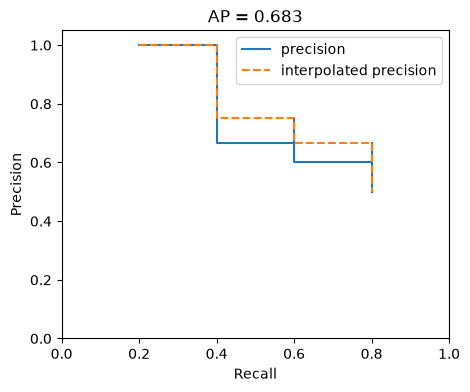

In [3]:
# トイデータでPrecision-Recall曲線とAPを計算する例
# 1クラス・1画像に対する検出結果（スコア降順）と、正検出(1)/誤検出(0)のラベル
scores_toy = np.array([0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3])
is_tp = np.array([1, 1, 0, 1, 0, 1, 0, 0])  # IoU>=0.5で正解と対応付けられたか
n_gt = 5  # この画像・クラスにおける正解ボックスの総数

tp_cum = np.cumsum(is_tp)
fp_cum = np.cumsum(1 - is_tp)
precision = tp_cum / (tp_cum + fp_cum)
recall = tp_cum / n_gt

# interpolated precision: 各recall水準でそれ以降のprecisionの最大値をとる
precision_interp = np.maximum.accumulate(precision[::-1])[::-1]

# 台形則ではなく、recallが変化した点でのprecisionを足し合わせる形でAPを近似
recall_padded = np.concatenate([[0], recall])
ap = np.sum((recall_padded[1:] - recall_padded[:-1]) * precision_interp)

fig, ax = plt.subplots(figsize=[5, 4])
ax.step(recall, precision, where="post", label="precision", color="tab:blue")
ax.step(recall, precision_interp, where="post", label="interpolated precision", color="tab:orange", linestyle="--")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title(f"AP = {ap:.3f}")
ax.legend()
plt.show()

## 検出パラダイムの概観

評価指標が共通していても、「どのように候補領域を生成し、どのように分類・回帰するか」という設計は手法によって大きく異なる。本ノートブック以下では、次の系統に分けて整理する。

| 系統 | 代表手法 | 基本アイデア |
| --- | --- | --- |
| Two-stage（二段階） | R-CNN, Fast R-CNN, Faster R-CNN | 領域候補を提案してから分類・回帰する |
| One-stage（一段階） | YOLO, SSD | グリッド／アンカーに対して1回の forward で直接予測する |
| Anchor-free | FCOS など | アンカーを使わずピクセル単位で直接予測する |
| Transformer系 | DETR, Deformable DETR, RT-DETR | 集合予測問題として定式化し、NMSなどの後処理を排除する |

## 参考文献

- [Mean Average Precision (mAP) Explained | Paperspace Blog](https://blog.paperspace.com/mean-average-precision/)
- [IoU (Intersection over Union) for object detection - PyImageSearch](https://pyimagesearch.com/2016/11/07/intersection-over-union-iou-for-object-detection/)
- Everingham, M. et al. (2010). [The PASCAL Visual Object Classes (VOC) Challenge](https://doi.org/10.1007/s11263-009-0275-4)
- Lin, T.-Y. et al. (2014). [Microsoft COCO: Common Objects in Context](https://arxiv.org/abs/1405.0312)